# Clasificación de Perros y Gatos con MLP

Este notebook desarrolla un modelo de clasificación binaria de imágenes (perro vs. gato) 
utilizando un Perceptrón Multicapa (MLP), a partir de una variante del dataset Oxford-IIIT Pet.

## 1. Introducción y exploración del dataset

En esta primera sección cargamos las imágenes, identificamos las clases (perro/gato) a 
partir del nombre de archivo, y exploramos las características generales del conjunto de datos.

**Justificación de la elección del dataset:** Se seleccionó Oxford-IIIT Pet por sobre las 
otras alternativas disponibles (Intel Image Classification, Los Simpson, PlantVillage) 
porque plantea un problema de clasificación con relevancia práctica directa (identificación 
de mascotas), cuenta con un tamaño de dataset manejable dentro del tiempo disponible para 
la evaluación, y su variabilidad natural en iluminación, postura y fondo lo convierte en 
un caso de estudio realista para evaluar las capacidades y limitaciones de un modelo MLP.

In [1]:
import os

data_dir = "../data/images/images"
archivos = [f for f in os.listdir(data_dir) if f.endswith(".jpg")]

print(f"Total de imágenes .jpg encontradas: {len(archivos)}")
print("Ejemplos de nombres de archivo:", archivos[:5])

Total de imágenes .jpg encontradas: 7390
Ejemplos de nombres de archivo: ['British_Shorthair_122.jpg', 'beagle_160.jpg', 'Ragdoll_142.jpg', 'english_setter_188.jpg', 'Maine_Coon_238.jpg']


## 2. Definición de la variante binaria (perro vs. gato)

El dataset original tiene 37 clases (razas). Para este proyecto, se define una variante 
binaria: cada imagen se etiqueta como "perro" o "gato" según si el nombre del archivo 
comienza con mayúscula (convención del dataset para razas de gato) o minúscula (razas de perro).

In [2]:
etiquetas = []

for archivo in archivos:
    primera_letra = archivo[0]
    if primera_letra.isupper():
        etiquetas.append("gato")
    else:
        etiquetas.append("perro")

from collections import Counter
conteo = Counter(etiquetas)
print("Conteo de imágenes por clase:")
print(conteo)

Conteo de imágenes por clase:
Counter({'perro': 4990, 'gato': 2400})


## 3. Hallazgo: desbalance de clases

Se observa un desbalance entre clases: 4.990 imágenes de perro (67.5%) y 2.400 imágenes 
de gato (32.5%). Este desbalance deberá considerarse durante el entrenamiento, ya que 
el modelo podría sesgarse hacia la clase mayoritaria (perro) si no se toman medidas 
correct

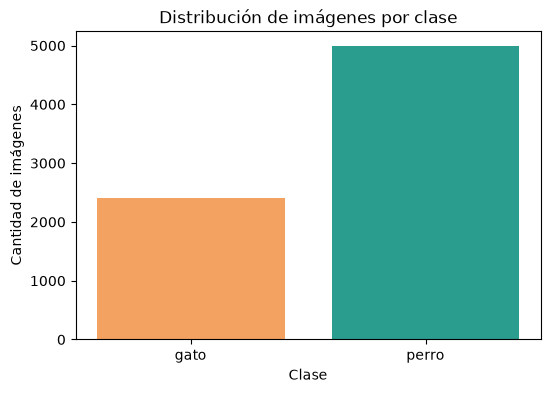

In [3]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.bar(conteo.keys(), conteo.values(), color=["#f4a261", "#2a9d8f"])
plt.title("Distribución de imágenes por clase")
plt.xlabel("Clase")
plt.ylabel("Cantidad de imágenes")
plt.savefig("../images/distribucion_clases.png")
plt.show()

## 4. Visualización de ejemplos por clase

A continuación se muestran algunas imágenes de ejemplo de cada clase, para inspeccionar 
visualmente la variabilidad de iluminación, postura y fondo mencionada anteriormente.

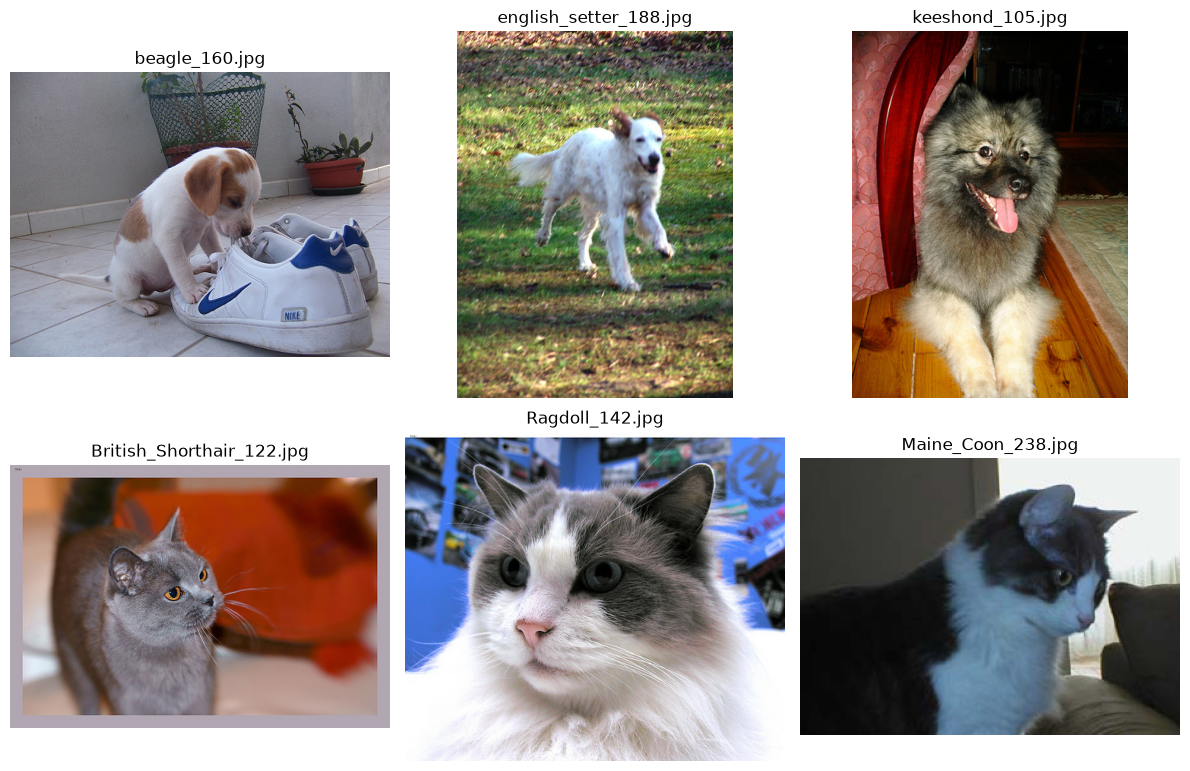

In [4]:
from PIL import Image

# Tomamos algunos ejemplos de cada clase
ejemplos_perro = [a for a in archivos if not a[0].isupper()][:3]
ejemplos_gato = [a for a in archivos if a[0].isupper()][:3]
ejemplos = ejemplos_perro + ejemplos_gato

fig, axes = plt.subplots(2, 3, figsize=(12, 8))

for i, archivo in enumerate(ejemplos):
    img = Image.open(os.path.join(data_dir, archivo))
    ax = axes[i // 3, i % 3]
    ax.imshow(img)
    ax.set_title(archivo)
    ax.axis("off")

plt.tight_layout()
plt.savefig("../images/ejemplos_por_clase.png")
plt.show()

## 5. Revisión de tamaños y resoluciones

Antes de definir el preprocesamiento, revisamos si las imágenes del dataset tienen 
tamaños uniformes o variables, ya que el MLP requiere una entrada de tamaño fijo.

In [5]:
import random

muestra = random.sample(archivos, 20)
tamanos = []

for archivo in muestra:
    img = Image.open(os.path.join(data_dir, archivo))
    tamanos.append(img.size)

print("Tamaños (ancho, alto) de 20 imágenes de muestra:")
for archivo, tamano in zip(muestra, tamanos):
    print(f"{archivo}: {tamano}")

anchos = [t[0] for t in tamanos]
altos = [t[1] for t in tamanos]
print(f"\nAncho promedio: {sum(anchos)/len(anchos):.0f} px")
print(f"Alto promedio: {sum(altos)/len(altos):.0f} px")

Tamaños (ancho, alto) de 20 imágenes de muestra:
Bombay_146.jpg: (220, 165)
scottish_terrier_177.jpg: (500, 333)
wheaten_terrier_148.jpg: (500, 333)
newfoundland_10.jpg: (335, 500)
english_setter_112.jpg: (335, 500)
Maine_Coon_191.jpg: (493, 500)
japanese_chin_7.jpg: (432, 499)
Birman_21.jpg: (500, 333)
american_pit_bull_terrier_80.jpg: (500, 333)
leonberger_196.jpg: (375, 500)
Abyssinian_165.jpg: (500, 353)
great_pyrenees_31.jpg: (500, 336)
keeshond_174.jpg: (500, 333)
pug_58.jpg: (357, 500)
staffordshire_bull_terrier_58.jpg: (385, 500)
Russian_Blue_161.jpg: (361, 500)
chihuahua_21.jpg: (342, 500)
pomeranian_58.jpg: (375, 500)
great_pyrenees_82.jpg: (500, 333)
keeshond_17.jpg: (500, 375)

Ancho promedio: 426 px
Alto promedio: 411 px


## 6. Hallazgo: tamaños variables

Se confirma que las imágenes del dataset tienen dimensiones variables (por ejemplo, desde 
287x300 hasta 762x571 píxeles), con un tamaño promedio aproximado de 437x402 px. Dado que 
un MLP requiere un vector de entrada de tamaño fijo, todas las imágenes deberán 
redimensionarse a una dimensión uniforme antes del entrenamiento.

## 7. Preparación y preprocesamiento de los datos

Se aplican las siguientes transformaciones a cada imagen antes de entrenar el modelo:

1. **Redimensionamiento** a un tamaño fijo de 32x32 píxeles, para reducir la dimensionalidad 
   y mantener un uso de memoria manejable con un MLP.
2. **Normalización** de los valores de píxeles al rango [0, 1], dividiendo por 255.
3. **Aplanado (flatten)** de cada imagen a un vector unidimensional, ya que el MLP no 
   procesa directamente la estructura 2D/3D de una imagen.

In [6]:
import numpy as np

TAMANO = (32, 32)

def cargar_y_procesar_imagen(ruta):
    img = Image.open(ruta).convert("RGB")
    img = img.resize(TAMANO)
    array = np.array(img) / 255.0
    return array.flatten()

X = []
y = []

for archivo in archivos:
    ruta = os.path.join(data_dir, archivo)
    try:
        vector = cargar_y_procesar_imagen(ruta)
        etiqueta = 1 if archivo[0].isupper() else 0  # 1 = gato, 0 = perro
        X.append(vector)
        y.append(etiqueta)
    except Exception as e:
        print(f"Error con {archivo}: {e}")

X = np.array(X)
y = np.array(y)

print(f"Forma de X: {X.shape}")
print(f"Forma de y: {y.shape}")

Forma de X: (7390, 3072)
Forma de y: (7390,)


## 8. División en conjuntos de entrenamiento y validación

Se divide el dataset en 80% para entrenamiento y 20% para validación, utilizando una 
semilla fija para garantizar la reproducibilidad de los resultados.

In [8]:
from sklearn.model_selection import train_test_split

SEMILLA = 42

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=SEMILLA, stratify=y
)

print(f"Entrenamiento: {X_train.shape[0]} imágenes")
print(f"Validación: {X_val.shape[0]} imágenes")
print(f"Proporción de gatos en train: {y_train.mean():.2%}")
print(f"Proporción de gatos en validación: {y_val.mean():.2%}")

Entrenamiento: 5912 imágenes
Validación: 1478 imágenes
Proporción de gatos en train: 32.48%
Proporción de gatos en validación: 32.48%


## 9. Diseño del Perceptrón Multicapa (MLP)

Se diseña una arquitectura MLP simple para el problema de clasificación binaria. La 
arquitectura considera:

- **Capa de entrada**: 3.072 neuronas (correspondientes a los píxeles de la imagen 32x32x3 aplanada)
- **Capas ocultas**: 2 capas ocultas con 128 y 64 neuronas respectivamente, usando función de activación ReLU
- **Capa de salida**: 1 neurona con función de activación sigmoide, adecuada para clasificación binaria
- **Función de pérdida**: binary crossentropy
- **Optimizador**: Adam
- **Métrica de seguimiento durante entrenamiento**: accuracy

Esta arquitectura se eligió por ser una configuración estándar y liviana para un problema 
de clasificación binaria, adecuada para evaluar el rendimiento base de un MLP antes de 
comparar con arquitecturas más especializadas.

**Justificación de hiperparámetros de entrenamiento:**
- **Épocas (20):** se eligió un número moderado de épocas para observar la evolución 
  completa del entrenamiento y detectar posibles signos de sobreajuste o estancamiento, 
  sin extender excesivamente el tiempo de cómputo disponible.
- **Batch size (32):** valor estándar que equilibra la velocidad de entrenamiento con la 
  estabilidad del gradiente, adecuado para el tamaño del dataset utilizado (~5.900 
  imágenes de entrenamiento).
- **Optimizador Adam:** se prefiere sobre el descenso de gradiente clásico por su tasa de 
  aprendizaje adaptativa, que facilita una convergencia más rápida y estable sin necesidad 
  de ajustar manualmente la tasa de aprendizaje.

In [10]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

modelo = Sequential([
    Dense(128, activation='relu', input_shape=(3072,)),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')
])

modelo.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

modelo.summary()

I0000 00:00:1788832495.739687   30227 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1788832501.439801   30227 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1788832514.049723   30227 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
/usr/local/python/3.12.1/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
E0000 00:00:1788832515.116033   30227 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed 

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       393,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 401,665 (1.53 MB)

 Trainable params: 401,665 (1.53 MB)

 Non-trainable params: 0 (0.00 B)

## 10. Entrenamiento del modelo

Se entrena el modelo utilizando el conjunto de entrenamiento, validando en cada época 
con el conjunto de validación. Se registra la evolución de la función de pérdida y la 
precisión (accuracy) durante el proceso.

In [11]:
historial = modelo.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=32
)

Epoch 1/20


W0000 00:00:1788832615.264010   30227 cpu_allocator_impl.cc:82] Allocation of 72646656 exceeds 10% of free system memory.


178/185 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6533 - loss: 0.6556

W0000 00:00:1788832618.644653   30227 cpu_allocator_impl.cc:82] Allocation of 18161664 exceeds 10% of free system memory.


185/185 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.6539 - loss: 0.6547 - val_accuracy: 0.6752 - val_loss: 0.6271
Epoch 2/20
185/185 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6757 - loss: 0.6257 - val_accuracy: 0.6752 - val_loss: 0.6315
Epoch 3/20
185/185 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6788 - loss: 0.6217 - val_accuracy: 0.6773 - val_loss: 0.6210
Epoch 4/20
185/185 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6752 - loss: 0.6166 - val_accuracy: 0.6752 - val_loss: 0.6293
Epoch 5/20
185/185 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.6803 - loss: 0.6115 - val_accuracy: 0.6759 - val_loss: 0.6175
Epoch 6/20
185/185 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6790 - loss: 0.6084 - val_accuracy: 0.6840 - val_loss: 0.6141
Epoch 7/20
185/185 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6783 - loss: 0.6137 - val_accuracy: 0.6752 - val_loss: 0.6240
Epoch 8/20
185/185 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.6850 - loss: 0.6058 - val_accuracy: 0.6725 - val_

## 11. Curvas de entrenamiento y validación

Se visualiza la evolución de la función de pérdida y la precisión durante el entrenamiento, 
para identificar el comportamiento de convergencia del modelo y posibles signos de 
sobreajuste o bajo aprendizaje.

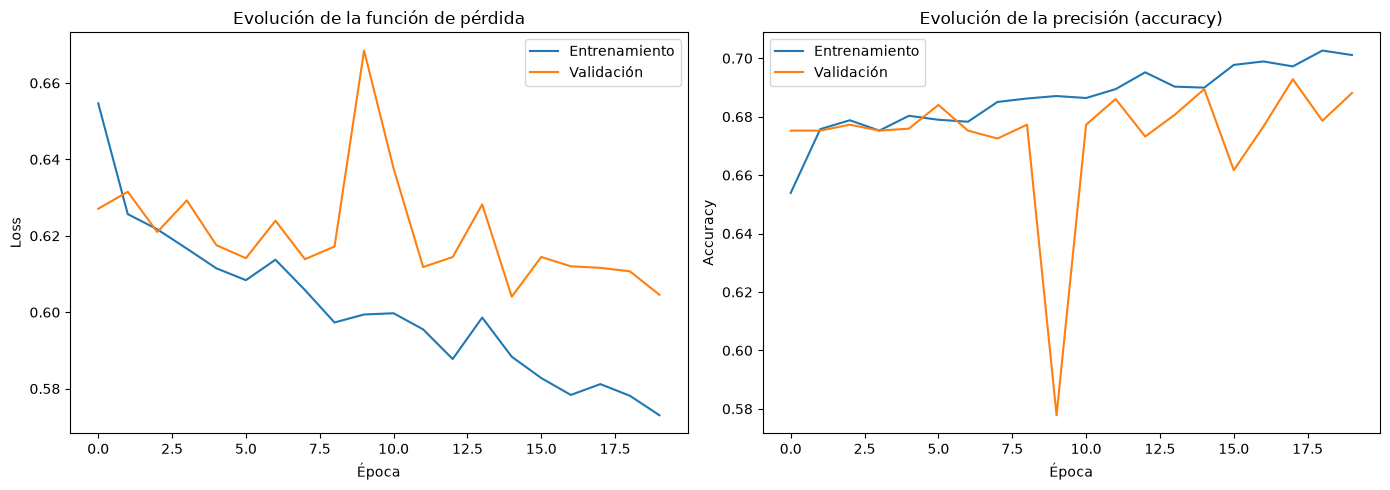

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(historial.history['loss'], label='Entrenamiento')
axes[0].plot(historial.history['val_loss'], label='Validación')
axes[0].set_title('Evolución de la función de pérdida')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(historial.history['accuracy'], label='Entrenamiento')
axes[1].plot(historial.history['val_accuracy'], label='Validación')
axes[1].set_title('Evolución de la precisión (accuracy)')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()
plt.savefig("../images/curvas_entrenamiento.png")
plt.show()

## 12. Evaluación del desempeño

Se evalúa el modelo utilizando múltiples métricas de clasificación: Accuracy, Precision, 
Recall, F1-Score y Matriz de Confusión, para comprender su comportamiento más allá del 
accuracy general.

18/47 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step  

W0000 00:00:1788833133.079304   30227 cpu_allocator_impl.cc:82] Allocation of 18161664 exceeds 10% of free system memory.


47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step
Reporte de clasificación:
              precision    recall  f1-score   support

       perro       0.69      0.99      0.81       998
        gato       0.73      0.06      0.12       480

    accuracy                           0.69      1478
   macro avg       0.71      0.53      0.46      1478
weighted avg       0.70      0.69      0.58      1478



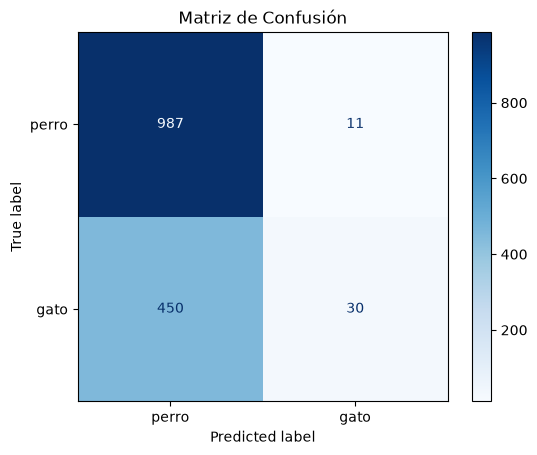

In [13]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Predicciones sobre el set de validación
y_pred_prob = modelo.predict(X_val)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

print("Reporte de clasificación:")
print(classification_report(y_val, y_pred, target_names=["perro", "gato"]))

# Matriz de confusión
cm = confusion_matrix(y_val, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["perro", "gato"])
disp.plot(cmap="Blues")
plt.title("Matriz de Confusión")
plt.savefig("../images/matriz_confusion.png")
plt.show()

## 13. Hallazgo: sesgo del modelo hacia la clase mayoritaria

A pesar de un accuracy general de 69%, el análisis por clase revela un problema serio: 
el modelo tiene un recall de apenas 6% para la clase "gato" (F1-Score: 0.12), mientras 
que para "perro" alcanza 99% de recall (F1-Score: 0.81). Esto confirma que el desbalance 
de clases detectado en el EDA (67.5% perro / 32.5% gato) llevó al modelo a adoptar una 
estrategia sesgada: predecir mayoritariamente "perro", lo que maximiza el accuracy general 
pero produce un modelo poco útil para identificar gatos.

## 14. Análisis de resultados y errores

Se revisan ejemplos específicos correctamente clasificados e incorrectamente clasificados, 
para entender mejor el comportamiento del modelo, especialmente los errores en la clase "gato".

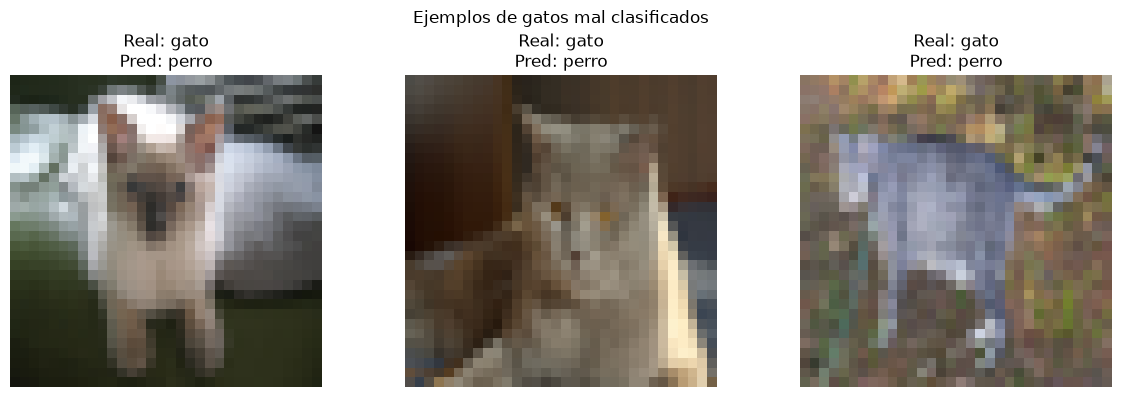

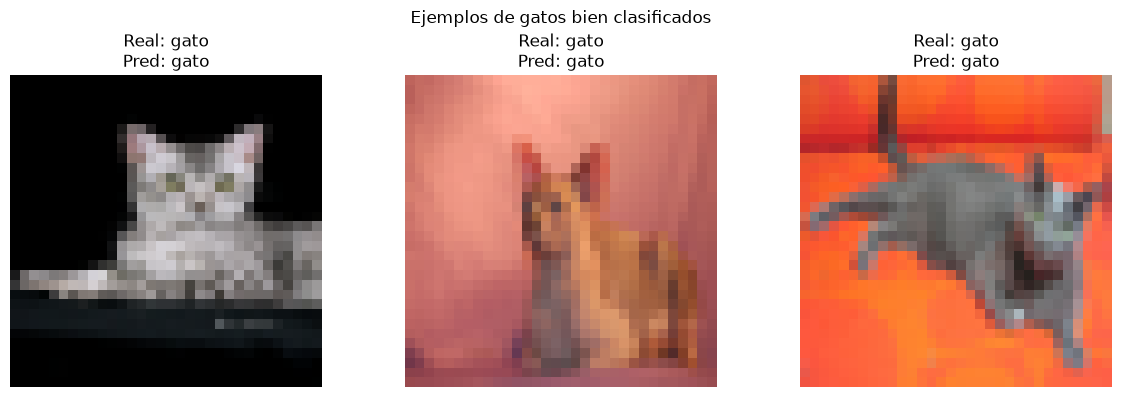

In [14]:
# Índices de aciertos y errores
indices_acierto = np.where(y_pred == y_val)[0]
indices_error = np.where(y_pred != y_val)[0]

# Tomamos ejemplos de gatos mal clasificados (el error más crítico detectado)
errores_gato = [i for i in indices_error if y_val[i] == 1][:3]
aciertos_gato = [i for i in indices_acierto if y_val[i] == 1][:3]

def mostrar_ejemplos(indices, titulo):
    fig, axes = plt.subplots(1, len(indices), figsize=(12, 4))
    for ax, idx in zip(axes, indices):
        img = X_val[idx].reshape(32, 32, 3)
        ax.imshow(img)
        pred_label = "gato" if y_pred[idx] == 1 else "perro"
        real_label = "gato" if y_val[idx] == 1 else "perro"
        ax.set_title(f"Real: {real_label}\nPred: {pred_label}")
        ax.axis("off")
    plt.suptitle(titulo)
    plt.tight_layout()
    return fig

fig1 = mostrar_ejemplos(errores_gato, "Ejemplos de gatos mal clasificados")
fig1.savefig("../images/errores_gato.png")
plt.show()

fig2 = mostrar_ejemplos(aciertos_gato, "Ejemplos de gatos bien clasificados")
fig2.savefig("../images/aciertos_gato.png")
plt.show()

### Observaciones del análisis de errores

En los casos de error, los gatos aparecen de cuerpo completo y a mayor distancia de la 
cámara, con una silueta general que puede confundirse con la de un perro pequeño. En los 
casos de acierto, los gatos están más cerca de la cámara, con rasgos faciales

## 15. Conclusiones

**Desempeño alcanzado:** El modelo MLP logró un accuracy general de 69% sobre el conjunto 
de validación, pero este resultado es engañoso: el F1-Score para la clase "gato" fue de 
apenas 0.12 (recall de 6%), mientras que para "perro" alcanzó 0.81. El modelo no cumplió 
la meta de accuracy planteada inicialmente (≥80%) ni la de F1-Score (≥0.75).

**Principales decisiones de diseño:** Se optó por reducir el problema a una clasificación 
binaria (perro/gato) en lugar de las 37 razas originales, se redimensionaron las imágenes 
a 32x32 píxeles para manejar las limitaciones de memoria del entorno, y se utilizó una 
arquitectura MLP simple de 2 capas ocultas (128 y 64 neuronas).

**Fortalezas:** El flujo de trabajo completo (carga, EDA, preprocesamiento, entrenamiento, 
evaluación y análisis de errores) se ejecutó de forma reproducible, con una semilla fija 
y documentación de cada etapa.

**Limitaciones:** 
- El desbalance de clases (67.5% perro / 32.5% gato) no fue corregido durante el 
  entrenamiento, lo que sesgó al modelo hacia la clase mayoritaria.
- El uso de un MLP implica aplanar la imagen, perdiendo toda la información espacial 
  (relaciones entre píxeles vecinos), lo que limita su capacidad de reconocer patrones 
  visuales como formas de orejas, hocico, etc.
- La reducción a 32x32 píxeles (necesaria por restricciones de memoria) probablemente 
  eliminó detalles finos relevantes para la clasificación.

**Posibles mejoras futuras:**
- Aplicar técnicas de balanceo de clases (oversampling de gatos, undersampling de perros, 
  o ponderación de clases en la función de pérdida).
- Utilizar arquitecturas más adecuadas para imágenes, como redes convolucionales (CNN), 
  que preservan la estructura espacial de la imagen.
- Aumentar la resolución de las imágenes si se cuenta con más recursos de memoria/cómputo.